# Lab 9: Premier Agent ADK pour Data Science

**Navigation** : [Lab 8 <<](../Day4-Foundations/Lab8-ADK-Introduction.ipynb) | [Index](../../README.md) | [>> Lab 10](../Day5-DS-Star/Lab10-File-Analyzer.ipynb)

## Objectifs d'apprentissage

À la fin de ce laboratoire, vous saurez :
1. Créer un agent simple capable d'exécuter du code Python
2. Analyser un DataFrame pandas avec l'agent
3. Comparer avec l'approche LangChain (`create_pandas_dataframe_agent`)
4. Tester avec différents providers (vLLM, Gemini)

### Prérequis
- Python 3.10+
- Fichier `.env` configuré avec `ACTIVE_PROVIDER`
- Connaissance de base des agents (Lab 7 complété)

### Durée estimée : 40-50 minutes

## 1. Configuration de l'Environnement

Nous utilisons notre couche d'abstraction multi-provider pour créer un agent capable d'exécuter du code Python.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
from io import StringIO
import json
import re

from config import get_settings, get_provider_config, ProviderType
from utils import LLMClient, generate

print("Imports OK : pandas, numpy, json, re, config, utils")

Imports OK : pandas, numpy, json, re, config, utils


Chargement de la configuration du provider.

In [2]:
# Chargement de la configuration
settings = get_settings()
config = get_provider_config(settings)

print(f"Provider: {config.provider.value}")
print(f"Modèle: {config.model}")

Provider: openai
Modèle: gpt-4o


## 2. Création d'un Dataset de Test

Nous créons un dataset de ventes simple pour tester notre agent.

In [3]:
# Création d'un dataset de ventes
np.random.seed(42)

data = {
    'date': pd.date_range('2024-01-01', periods=100, freq='D'),
    'product': np.random.choice(['Widget A', 'Widget B', 'Gadget X', 'Gadget Y'], 100),
    'region': np.random.choice(['Nord', 'Sud', 'Est', 'Ouest'], 100),
    'quantity': np.random.randint(1, 50, 100),
    'price': np.random.uniform(10, 100, 100).round(2)
}

df = pd.DataFrame(data)
df['revenue'] = df['quantity'] * df['price']

# Sauvegarde pour l'agent
df.to_csv('sales_data.csv', index=False)

print(f"Dataset créé: {len(df)} lignes")
df.head()

Dataset créé: 100 lignes


,date,product,region,quantity,price,revenue
0,2024-01-01,Gadget X,Est,32,11.49,367.68
1,2024-01-02,Gadget Y,Sud,39,56.09,2187.51
2,2024-01-03,Widget A,Sud,49,30.38,1488.62
3,2024-01-04,Gadget X,Ouest,32,68.07,2178.24
4,2024-01-05,Gadget X,Sud,4,25.69,102.76


### Lecture du dataset

**Structure.** 100 lignes, une par vente : une date quotidienne (série `date_range` démarrant au 2024-01-01), un produit parmi 4 (`Widget A`, `Widget B`, `Gadget X`, `Gadget Y`), une région parmi 4 (`Nord`, `Sud`, `Est`, `Ouest`), une quantité (1 à 50) et un prix (10 à 100). La colonne `revenue` est **dérivée** : `quantity × price` — vérifiez sur la première ligne du `head` ci-dessus : 32 × 11,49 = 367,68.

**Reproductibilité.** `np.random.seed(42)` en tête de cellule : rejouer la cellule redonne *exactement* le même dataset — et donc les mêmes résultats dans tout le reste du laboratoire. C'est la condition pour que les valeurs citées dans les interprétations qui suivent (revenus par région, podiums mensuels) restent vraies à la ré-exécution.

**Pourquoi `to_csv`.** L'agent ne reçoit pas le DataFrame en mémoire : il le découvre à travers le résumé injecté dans son prompt système (section 3). Sauvegarder `sales_data.csv` matérialise les données sur disque — utile pour recharger ou partager le même jeu de test sans dépendre de l'état du kernel.

**Une limite à garder en tête.** 100 jours à partir du 1er janvier : la couverture temporelle s'arrête début avril. Ce détail deviendra central à la question 2.

## 3. Implémentation d'un Agent Simple avec Code Exécution

Contrairement à LangChain qui fournit `create_pandas_dataframe_agent`, nous allons construire notre propre agent avec une capacité d'exécution de code Python.

> **Repère bibliographique.** Cet agent suit le paradigme **CodeAct** : au lieu d'émettre des appels d'outils séparés (action space JSON), le LLM génère du code Python *exécutable* que l'environnement interprète directement, ce qui lui permet de réviser ou d'enchaîner ses actions sur la base des résultats observés. Ce design est formalisé par X. Wang et al., *Executable Code Actions Elicit Better LLM Agents* (CodeAct), arXiv:2402.01030, ICML 2024. Il sous-tend les agents data-science modernes (Data Interpreter, CodeAct-2) qui atteignent l'état de l'art sur les benchmarks Kaggle et MLE-bench.

### Architecture

```
┌─────────────┐
│   Prompt    │  Question utilisateur + contexte DataFrame
└──────┬──────┘
       │
       v
┌─────────────┐
│    LLM      │  Génère du code Python
└──────┬──────┘
       │
       v
┌─────────────┐
│  Executor   │  Exécute le code de façon sécurisée
└──────┬──────┘
       │
       v
┌─────────────┐
│   Output    │  Résultat + explication
└─────────────┘
```

Le même pipeline **CodeAct**, rendu sous forme de graphe. Le trait plein reprend le flux
linéaire dessiné ci-dessus ; le trait tireté ajoute la boucle de **révision** décrite dans le
repère bibliographique (« réviser ou enchaîner ses actions sur la base des résultats observés ») :

```mermaid
flowchart TD
    PR["Prompt<br/>question + contexte DataFrame"]
    LLM["LLM<br/>génère du code Python"]
    EX["Executor<br/>exécute de façon sécurisée"]
    OUT["Output<br/>résultat + explication"]
    PR --> LLM
    LLM --> EX
    EX --> OUT
    OUT -.->|"révision (CodeAct)"| LLM
    classDef prompt fill:#cfe2ff,stroke:#084298,color:#052c65
    classDef llm fill:#fff3cd,stroke:#b8860b,color:#5c4400
    classDef exec fill:#d1e7dd,stroke:#0f5132,color:#052e16
    classDef out fill:#e2e3e5,stroke:#41464b,color:#1b1e21
    class PR prompt
    class LLM llm
    class EX exec
    class OUT out
```

> **Lecture.** Contrairement à un appel d'outil JSON figé, le paradigme **CodeAct** fait
> *générer du code exécutable* par le LLM : la sortie de l'**Executor** est ré-injectée dans le
> **LLM** (arête tiretée `révision`), qui peut corriger une erreur ou enchaîner l'étape suivante
> à partir de ce qu'il a *observé*. C'est cette rétroaction code ↔ exécution qui rend l'agent
> capable de s'auto-corriger, et qui sous-tend les data-science agents SOTA (Data Interpreter,
> CodeAct-2) évoqués dans le repère bibliographique ci-dessus.


In [4]:
class SimpleDataAgent:
    """
    Agent simple pour l'analyse de données avec exécution de code Python.
    
    Cette implémentation simplifiée montre les concepts clés d'un agent
    de data science sans utiliser de framework complexe.
    """
    
    def __init__(self, df: pd.DataFrame, client: LLMClient):
        """
        Initialise l'agent avec un DataFrame et un client LLM.
        
        Args:
            df: DataFrame pandas à analyser
            client: Client LLM pour la génération
        """
        self.df = df
        self.client = client
        self.df_name = 'df'
        
    def _get_system_prompt(self) -> str:
        """Génère le prompt système avec le contexte du DataFrame."""
        df_info = f"""DataFrame: {self.df_name}
Colonnes: {list(self.df.columns)}
Types: {self.df.dtypes.to_dict()}
Shape: {self.df.shape}
Premières lignes:
{self.df.head(3).to_string()}
Statistiques descriptives:
{self.df.describe().to_string()}
"""
        
        return f"""Tu es un expert en analyse de données. Tu as accès à un DataFrame pandas.

{df_info}

INSTRUCTIONS:
1. Pour répondre aux questions, génère UNIQUEMENT du code Python valide
2. Le code doit être entouré de balises ```python ... ```
3. Utilise print() pour afficher les résultats
4. Le DataFrame est disponible dans la variable '{self.df_name}'
5. Après le code, fournis une brève explication en français

EXEMPLE:
Question: Quelle est la moyenne des ventes?
Réponse:
```python
print(df['revenue'].mean())
```
La moyenne des revenus est affichée ci-dessus.
"""

    def _extract_code(self, response: str) -> str:
        """Extrait le code Python de la réponse du LLM."""
        # Recherche du code entre balises ```python ... ```
        pattern = r'```python\s*(.*?)\s*```'
        matches = re.findall(pattern, response, re.DOTALL)
        
        if matches:
            return matches[0]
        
        # Fallback: cherche n'importe quel bloc de code
        pattern = r'```\s*(.*?)\s*```'
        matches = re.findall(pattern, response, re.DOTALL)
        return matches[0] if matches else ""

    def _execute_code(self, code: str) -> str:
        """
        Exécute le code Python de façon sécurisée.
        
        WARNING: Cette implémentation est simplifiée pour l'enseignement.
        Pour la production, utilisez un sandbox (Docker, RestrictedPython, etc.)
        """
        # Création d'un namespace limité
        namespace = {
            'df': self.df,
            'pd': pd,
            'np': np,
            'print': print,
        }
        
        # Capture de la sortie
        from io import StringIO
        import sys
        
        old_stdout = sys.stdout
        sys.stdout = StringIO()
        
        try:
            exec(code, namespace)
            output = sys.stdout.getvalue()
        except Exception as e:
            output = f"Erreur: {str(e)}"
        finally:
            sys.stdout = old_stdout
            
        return output
    
    def analyze(self, question: str) -> str:
        """
        Analyse le DataFrame en répondant à une question.
        
        Args:
            question: Question sur les données
            
        Returns:
            Réponse avec code exécuté et explication
        """
        # Génération de la réponse
        response = self.client.generate(
            prompt=question,
            system=self._get_system_prompt(),
            temperature=0.1  # Basse température pour du code déterministe
        )
        
        # Extraction et exécution du code
        code = self._extract_code(response)
        
        if code:
            output = self._execute_code(code)
            return {
                'response': response,
                'code': code,
                'output': output
            }
        
        return {
            'response': response,
            'code': None,
            'output': None
        }

print("Classe SimpleDataAgent definie : analyse de DataFrame via generation + execution de code Python")

Classe SimpleDataAgent definie : analyse de DataFrame via generation + execution de code Python


### Lecture de l'implémentation : trois briques, une passe unique

La classe ci-dessus tient en trois méthodes privées plus une méthode publique, et chacune porte une décision de conception :

- **`_get_system_prompt`** — le contexte passé au LLM n'est pas seulement la question : il embarque les **colonnes**, les **dtypes**, la **shape**, les 3 premières lignes (`head(3).to_string()`) et les **statistiques descriptives complètes** (`describe()`). Le LLM « voit » le dataset sans jamais le manipuler : il sait avant d'écrire une ligne si `revenue` est numérique et dans quelle fourchette se situent les valeurs. Suit un bloc d'instructions (répondre uniquement par du code Python, balises `` ```python ``, `print()` pour afficher) et un **exemple few-shot** qui fixe le format de réponse attendu.

- **`_extract_code`** — la réponse du LLM est du texte mêlé ; le code est récupéré par une expression régulière sur les balises `` ```python ... ``` ``, avec un repli sur n'importe quel bloc `` ``` `` si la balise de langue manque. C'est la version minimale d'un *parser* de sortie.

- **`_execute_code`** — le cœur potentiellement dangereux : `exec` dans un **namespace limité** à `{df, pd, np, print}`, avec `stdout` redirigé vers un `StringIO` pour capturer la sortie, et toute exception attrapée puis rendue comme chaîne `Erreur: ...` (on verra cette chaîne en action à la section 6). La docstring le dit explicitement : ceci est un garde-fou pédagogique, **pas un sandbox** — en production, l'exécution se conteneurise (Docker, gVisor, RestrictedPython ; voir la section 7).

- **`analyze`** — enchaîne le tout : génération (`temperature=0.1`), extraction, exécution, et retour du triplet `{response, code, output}`. Une seule passe, pas de boucle : la révision CodeAct du graphe de la section 3 n'est pas implémentée ici — on le constatera concrètement sur l'échec de la section 6.

## 4. Test de l'Agent

In [5]:
# Création de l'agent
client = LLMClient()
agent = SimpleDataAgent(df, client)

print("Agent créé avec succès!")
print(f"Provider: {client.config.provider.value}")
print(f"Modèle: {client.config.model}")

Agent créé avec succès!
Provider: openai
Modèle: gpt-4o


### Question 1: Statistiques de base

In [6]:
result = agent.analyze("Quel est le revenu total par région?")

print("=== CODE GÉNÉRÉ ===")
print(result['code'])
print("\n=== RÉSULTAT ===")
print(result['output'])
print("\n=== RÉPONSE COMPLETE ===")
print(result['response'])

=== CODE GÉNÉRÉ ===
print(df.groupby('region')['revenue'].sum())

=== RÉSULTAT ===
region
Est      44451.45
Nord     33944.31
Ouest    32673.99
Sud      40079.60
Name: revenue, dtype: float64


=== RÉPONSE COMPLETE ===
```python
print(df.groupby('region')['revenue'].sum())
```
Le code ci-dessus calcule et affiche le revenu total pour chaque région en regroupant les données par la colonne 'region' et en sommant les valeurs de la colonne 'revenue'.


### Lecture du résultat

**Les chiffres.** Les quatre régions totalisent des revenus du même ordre de grandeur : Est 44 451,45 en tête, puis Sud 40 079,60, Nord 33 944,31 et Ouest 32 673,99 — un écart d'environ 1,4× entre la première et la dernière. Avec 100 ventes réparties aléatoirement sur 4 régions (seed 42), on *attend* des totaux proches : c'est exactement ce qu'on observe, aucune région ne se détache du bruit d'échantillonnage.

**Le triplet de sortie.** La cellule affiche trois sections — `CODE GÉNÉRÉ`, `RÉSULTAT`, `RÉPONSE COMPLETE` — qui correspondent aux trois artefacts du paradigme CodeAct : le code que le LLM a écrit, ce que son exécution a produit, et l'explication qui accompagne le tout (exigée par l'instruction 5 du prompt système). Sur une question simple, le code tient en une ligne idiomatique — `df.groupby('region')['revenue'].sum()` — exactement ce qu'un analyste écrirait à la main : le cadrage du prompt système (colonnes, types, exemple few-shot) suffit à obtenir une génération propre.

**Notez la température.** `analyze()` appelle le LLM avec `temperature=0.1` : pour du code, on veut de la reproductibilité, pas de la créativité — une variation de formulation dans le code généré est un bug potentiel, pas une feature.

### Question 2: Analyse temporelle

In [7]:
result = agent.analyze("Quel est le produit le plus vendu par mois? Montre le top 3 pour chaque mois.")

print("=== CODE GÉNÉRÉ ===")
print(result['code'])
print("\n=== RÉSULTAT ===")
print(result['output'])

=== CODE GÉNÉRÉ ===
# Convertir la colonne 'date' en type datetime si ce n'est pas déjà fait
df['date'] = pd.to_datetime(df['date'])

# Extraire le mois et l'année de la date
df['year_month'] = df['date'].dt.to_period('M')

# Grouper par mois et produit, puis sommer les quantités
monthly_sales = df.groupby(['year_month', 'product'])['quantity'].sum().reset_index()

# Trier les résultats par mois et par quantité décroissante
monthly_sales_sorted = monthly_sales.sort_values(by=['year_month', 'quantity'], ascending=[True, False])

# Obtenir le top 3 des produits les plus vendus pour chaque mois
top_3_products_per_month = monthly_sales_sorted.groupby('year_month').head(3)

print(top_3_products_per_month)

=== RÉSULTAT ===
   year_month   product  quantity
1     2024-01  Gadget Y       236
0     2024-01  Gadget X       232
2     2024-01  Widget A       214
5     2024-02  Gadget Y       275
4     2024-02  Gadget X       204
6     2024-02  Widget A       138
9     2024-03  Gadget Y       234


### Lecture : le piège d'avril

Le code généré est nettement plus élaboré qu'à la question 1 — conversion `datetime`, extraction du mois par `dt.to_period('M')`, agrégation à deux niveaux `['year_month', 'product']`, tri décroissant, puis `groupby('year_month').head(3)` pour ne garder que le podium de chaque mois. C'est l'exemple type d'une question qu'un simple grouper-sommer ne suffit pas à couvrir : la richesse de la requête se retrouve dans la richesse du code.

**Le podium.** Gadget Y domine nettement janvier (236), février (275) et mars (234) ; Widget A et Gadget X se disputent les places suivantes ; en mars, Widget B (212) remonte au deuxième rang.

**Le piège.** Avril affiche des quantités minuscules — Widget B 113, Widget A 36, Gadget Y 19. Lecture naïve : « effondrement des ventes en avril ». Vérification de couverture temporelle : le dataset de la section 2 est `pd.date_range('2024-01-01', periods=100, freq='D')` — 100 jours, soit du 1er janvier au **9 avril 2024**. Avril ne porte que ~9 jours de ventes contre 29 à 31 pour les mois pleins : la chute d'avril est un **artefact de troncature**, pas un signal métier. Avant d'interpréter une saisonnalité, on vérifie que les périodes comparées couvrent des durées comparables — c'est aussi pourquoi la question ambiguë « Compare avec l'année précédente » de l'exercice de robustesse est impossible : le dataset ne contient qu'une seule année.

### Question 3: Visualisation

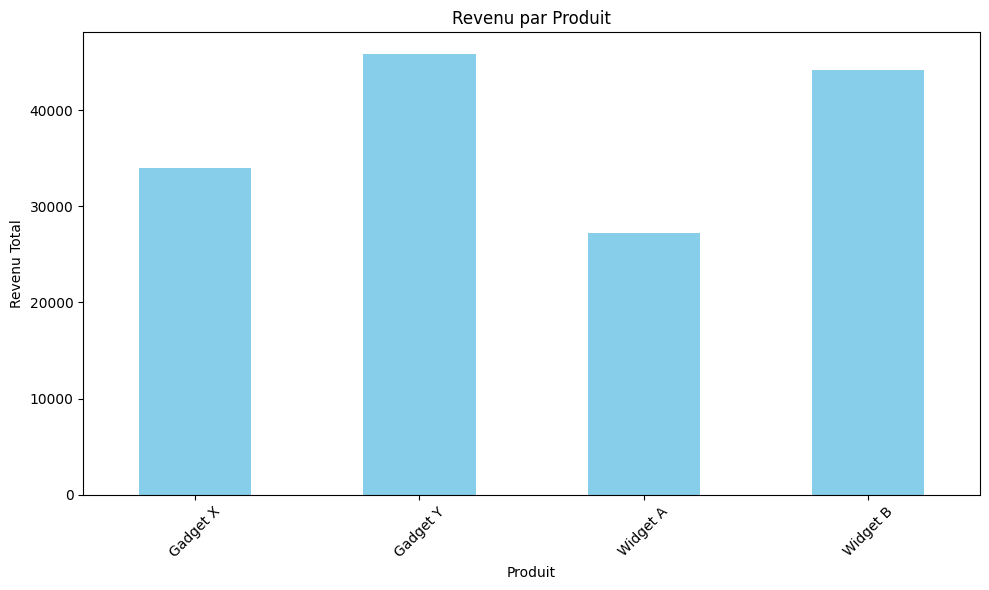

=== CODE GÉNÉRÉ ===
import matplotlib.pyplot as plt

# Calculer le revenu total par produit
revenue_by_product = df.groupby('product')['revenue'].sum()

# Créer un graphique à barres
plt.figure(figsize=(10, 6))
revenue_by_product.plot(kind='bar', color='skyblue')
plt.title('Revenu par Produit')
plt.xlabel('Produit')
plt.ylabel('Revenu Total')
plt.xticks(rotation=45)
plt.tight_layout()

# Afficher le graphique
plt.show()

=== RÉSULTAT ===



In [8]:
result = agent.analyze("Crée un graphique à barres montrant le revenu par produit. Utilise matplotlib.")

print("=== CODE GÉNÉRÉ ===")
print(result['code'])
print("\n=== RÉSULTAT ===")
print(result['output'])

### Lecture : la figure est là, mais la sortie capturée est vide

Trois choses à lire dans cette sortie :

1. **Le code généré** fait le travail complet en style pandas idiomatique : agrégation `groupby('product')['revenue'].sum()`, puis rendu via l'API `.plot(kind='bar')` avec les habillages (`title`, `xlabel`, `ylabel`, `rotation=45`, `tight_layout`). La question imposait « Utilise matplotlib » : le LLM a importé `matplotlib.pyplot` lui-même — logique, l'agent simple n'injecte pas encore `plt` dans son namespace (ce sera le rôle de l'agent étendu, section 6).

2. **La section `=== RÉSULTAT ===` est vide**, alors que la figure s'affiche bien dans la cellule. Ce n'est pas un bug : `_execute_code` capture `stdout` via un `StringIO`, mais `plt.show()` ne passe pas par `stdout` — le rendu part vers le backend d'affichage du kernel, qui l'émet comme image. Le mécanisme de capture de l'agent est **aveugle aux figures** : c'est une limite structurelle de ce design, et elle motive la valeur de retour textuelle des tools `plot_*` de la section 6.

3. **Croisez la figure avec la question 2.** Le graphique classe les produits par *revenu* cumulé, la question 2 les classait par *quantité*. Quand le prix unitaire varie de 10 à 100 (bornes posées à la construction du dataset, section 2), vendre beaucoup d'unités et générer beaucoup de revenu sont deux podiums différents — comparez les deux classements avant de conclure « meilleur produit ». C'est exactement l'ambiguïté que l'exercice « Robustesse » de la section 8 vous demandera de documenter.

## 5. Comparaison avec LangChain

### Approche LangChain

```python
from langchain_experimental.agents import create_pandas_dataframe_agent
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4")
agent = create_pandas_dataframe_agent(llm, df, verbose=True)
agent.invoke("Quel est le revenu total par région?")
```

### Différences Clés

| Aspect | Notre Agent Simple | LangChain Agent |
|--------|-------------------|-----------------|
| **Dépendances** | Minimal (litellm, pandas) | langes chaînes de dépendances |
| **Contrôle** | Full contrôle sur l'exécution | Abstraction, moins visible |
| **Sécurité** | À implémenter soi-même | Intégré (PythonAstREPLTool) |
| **Multi-provider** | Natif via notre config | Nécessite adapters |
| **Debugging** | Facile (code visible) | Plus complexe |

### Avantages de Notre Approche

1. **Léger**: Pas de dépendances lourdes
2. **Pédagogique**: On comprend chaque composant
3. **Flexible**: Facile d'ajouter des tools personnalisés
4. **Multi-provider**: Fonctionne avec n'importe quel LLM

## 6. Amélioration: Ajout de Tools Supplémentaires

Étendons notre agent avec des tools spécialisés.

In [9]:
class EnhancedDataAgent(SimpleDataAgent):
    """
    Agent étendu avec des tools supplémentaires.
    """
    
    def _get_system_prompt(self) -> str:
        base_prompt = super()._get_system_prompt()
        
        tools_info = """
TOOLS DISPONIBLES:
1. df_info() - Affiche les infos du DataFrame
2. df_describe() - Statistiques descriptives
3. df_columns() - Liste des colonnes avec types
4. plot_bar(x, y, title) - Crée un graphique à barres
5. plot_line(x, y, title) - Crée un graphique linéaire
6. plot_pie(values, labels, title) - Crée un graphique circulaire
"""
        return base_prompt + tools_info
    
    def _execute_code(self, code: str) -> str:
        """Exécution avec outils additionnels."""
        import matplotlib.pyplot as plt
        
        # Tools helpers
        def df_info():
            return self.df.info()
        
        def df_describe():
            return self.df.describe()
        
        def df_columns():
            return self.df.dtypes
        
        def plot_bar(x, y, title=""):
            plt.figure(figsize=(10, 6))
            self.df.groupby(x)[y].sum().plot(kind='bar')
            plt.title(title)
            plt.tight_layout()
            plt.show()
            return f"Graphique créé: {title}"
        
        def plot_line(x, y, title=""):
            plt.figure(figsize=(10, 6))
            self.df.plot(x=x, y=y, kind='line')
            plt.title(title)
            plt.tight_layout()
            plt.show()
            return f"Graphique créé: {title}"
        
        def plot_pie(values, labels, title=""):
            plt.figure(figsize=(8, 8))
            self.df.groupby(labels)[values].sum().plot(kind='pie', autopct='%1.1f%%')
            plt.title(title)
            plt.show()
            return f"Graphique créé: {title}"
        
        namespace = {
            'df': self.df,
            'pd': pd,
            'np': np,
            'plt': plt,
            'df_info': df_info,
            'df_describe': df_describe,
            'df_columns': df_columns,
            'plot_bar': plot_bar,
            'plot_line': plot_line,
            'plot_pie': plot_pie,
            'print': print,
        }
        
        from io import StringIO
        import sys
        
        old_stdout = sys.stdout
        sys.stdout = StringIO()
        
        try:
            exec(code, namespace)
            output = sys.stdout.getvalue()
        except Exception as e:
            output = f"Erreur: {str(e)}"
        finally:
            sys.stdout = old_stdout
            
        return output

print("Classe EnhancedDataAgent definie : agent etendu avec outils de visualisation (plot_bar, plot_line, plot_pie)")

Classe EnhancedDataAgent definie : agent etendu avec outils de visualisation (plot_bar, plot_line, plot_pie)


### Le pattern « tool » : deux moitiés qui doivent rester synchrones

L'ajout d'un tool à cet agent ne se joue pas à un seul endroit, mais à **deux**, dans deux méthodes différentes :

1. **Déclarer** le tool dans `_get_system_prompt` (bloc `TOOLS DISPONIBLES`, items 1 à 6) : sans cette ligne, le LLM ne sait pas que la fonction existe et ne l'appellera jamais ;
2. **L'injecter** dans le `namespace` de `_execute_code` : sans cette entrée, le tool est annoncé mais absent, et le premier appel lèvera un `NameError`.

Les deux moitiés se désynchronisent silencieusement : un tool présent dans le namespace mais non annoncé est du code mort ; un tool annoncé mais non injecté est un piège. L'exercice « Tool Personnalisé » de la section 8 vous fera exécuter ce geste en entier pour `detect_outliers` — les deux moitiés, pas une seule.

Notez aussi deux différences vis-à-vis de l'agent simple :

- `plt` (matplotlib) est désormais **injecté** dans le namespace : l'agent simple laissait le LLM importer lui-même `matplotlib.pyplot`, comme il l'a fait à la question 3 ;
- les fonctions `plot_*` **retournent une chaîne** (`"Graphique créé: {title}"`) : une figure rendue par `plt.show()` ne passe pas par `stdout` (constaté à la question 3), donc sans valeur de retour textuelle le LLM n'aurait aucun feedback d'exécution à lire.

Test de l'agent etendu avec des requêtes plus complexes.

In [10]:
# Test de l'agent étendu
enhanced_agent = EnhancedDataAgent(df, client)

result = enhanced_agent.analyze("Utilise plot_pie pour montrer la répartition du revenu par région.")

print("=== CODE GÉNÉRÉ ===")
print(result['code'])
print("\n=== RÉSULTAT ===")
print(result['output'])

=== CODE GÉNÉRÉ ===
revenue_by_region = df.groupby('region')['revenue'].sum()
plot_pie(values=revenue_by_region, labels=revenue_by_region.index, title='Répartition du revenu par région')

=== RÉSULTAT ===
Erreur: Grouper and axis must be same length


<Figure size 800x800 with 0 Axes>

### Lecture de l'échec : un tool mal documenté est un tool mal appelé

La sortie ci-dessus porte une **erreur réelle**, committée telle quel — et c'est précisément elle qui fait la valeur pédagogique de cette section. Décortiquons-la.

**Ce que le LLM a généré.** Le code agrège d'abord le revenu par région (une Series de 4 valeurs), puis la passe telle quelle au tool : `plot_pie(values=revenue_by_region, labels=revenue_by_region.index, ...)`. Le LLM a interprété `values` et `labels` comme des **données**.

**Ce que la signature attend.** Relisez `plot_pie` dans la cellule précédente : elle fait `self.df.groupby(labels)[values].sum()` — ses paramètres sont des **noms de colonnes**, pas des données. Avec un `labels` de 4 éléments face à un DataFrame de 100 lignes, le `groupby` échoue : `Grouper and axis must be same length`. La figure `800x800 with 0 Axes` est le sous-produit du `plt.figure(figsize=(8, 8))` exécuté juste avant l'échec.

**Où est le défaut ?** Pas dans le LLM, mais dans la **documentation du tool**. Le prompt système annonce `plot_pie(values, labels, title) - Crée un graphique circulaire` sans dire si les arguments sont des noms de colonnes ou des données : le LLM a dû **deviner** la convention d'appel — et il a deviné faux. Un tool dont la sémantique n'est pas écrite dans le prompt est un tool qui sera appelé au hasard.

**Pourquoi l'agent ne s'est pas corrigé.** Rappelez-vous le graphe CodeAct de la section 3 : l'arête tiretée « révision » suppose que l'erreur est *ré-injectée* au LLM. La méthode `analyze()` ne le fait pas — elle exécute **une fois** et retourne le triplet (code, output, réponse). Cette implémentation pédagogique est un CodeAct *sans boucle* ; la capacité d'auto-correction du paradigme complet est décrite dans la référence 1. C'est aussi le terrain de l'exercice « Robustesse » de la section 8, dont la catégorie `impossible_a_executer` couvre exactement ce type d'échec.

## 7. Résumé et Points Clés

### Ce que nous avons appris

1. **Architecture d'un Agent**: Composants LLM, Executor, Tools
2. **Code Exécution**: Exécuter du code généré par le LLM
3. **Tools**: Ajouter des fonctions spécialisées
4. **Multi-provider**: Fonctionne avec n'importe quel LLM configuré

### Sécurité (IMPORTANT)

⚠️ L'exécution de code générée par un LLM présente des risques:

- **Pour le développement**: Notre approche simple suffit
- **Pour la production**: Utilisez un sandbox (Docker, gVisor, RestrictedPython)
- **Jamais**: N'exécutez pas de code non validé sur des données sensibles

### Prochaines étapes

- **Lab 10**: File Analyzer de DS-STAR
- **Lab 11**: Boucle Planner-Coder-Verifier
- **Lab 12**: DS-STAR complet

## 8. Exercice

1. Posez 3 questions supplémentaires à l'agent
2. Ajoutez un tool `plot_histogram(column, bins=10)`
3. Testez avec un autre provider (changez `ACTIVE_PROVIDER` dans `.env`)

In [11]:
# Espace pour vos exercices

# Question 1:
# result = agent.analyze("Votre question ici")
# print(result['output'])

# Question 2:

# Question 3:

print("Exercice a completer")

Exercice a completer


## Exercice : Tool Personnalise pour l'Agent

Ajoutez un nouveau tool `detect_outliers(column, method='iqr')` a l'agent `EnhancedDataAgent`. Ce tool doit detecter les valeurs aberrantes dans une colonne numérique et retourner le nombre d'outliers et leurs indices.

### Objectifs
1. Implementer une fonction `detect_outliers` utilisant la méthode IQR (Interquartile Range)
2. L'integrer dans le namespace de `_execute_code`
3. Tester l'agent sur la colonne `price` du DataFrame de ventes

**Indice :**
- IQR = Q3 - Q1. Un outlier est une valeur < Q1 - 1.5*IQR ou > Q3 + 1.5*IQR
- Ajoutez votre fonction dans le dictionnaire `namespace` de `_execute_code`
- N'oubliez pas de mentionner le tool dans `_get_system_prompt`

In [12]:
# Exercice : Ajout d'un tool detect_outliers a l'agent
# Objectif : Implementer un outil de detection de valeurs aberrantes

# TODO: Definissez la fonction detect_outliers
def detect_outliers(column, method='iqr'):
    """
    Detecte les valeurs aberrantes dans une colonne du DataFrame.
    
    Args:
        column: nom de la colonne a analyser
        method: methode de detection ('iqr' ou 'zscore')
    
    Returns:
        dict avec le nombre d'outliers et leurs indices
    """
    # Etape 1: Recuperez les donnees de la colonne depuis le DataFrame
    # data = df[column]
    
    # Etape 2: Calculez Q1, Q3 et l'IQR
    # Q1 = data.quantile(0.25)
    # Q3 = data.quantile(0.75)
    # IQR = Q3 - Q1
    
    # Etape 3: Identifiez les outliers
    # lower = Q1 - 1.5 * IQR
    # upper = Q3 + 1.5 * IQR
    # outliers_mask = (data < lower) | (data > upper)
    
    # Etape 4: Retournez les resultats
    # return {"count": outliers_mask.sum(), "indices": data[outliers_mask].index.tolist()}
    
    return None  # TODO etudiant : remplacez par votre implementation

# TODO: Creez une classe OutlierDataAgent qui herite de EnhancedDataAgent
# et ajoute detect_outliers dans le namespace et dans le system prompt
# class OutlierDataAgent(EnhancedDataAgent):
#     def _get_system_prompt(self):
#         ... ajoutez "7. detect_outliers(column) - Detecte les valeurs aberrantes"
#     def _execute_code(self, code):
#         ... ajoutez detect_outliers dans le namespace

# TODO: Testez l'agent avec une question sur les outliers
# outlier_agent = OutlierDataAgent(df, client)
# result = outlier_agent.analyze("Y a-t-il des valeurs aberrantes dans les prix ?")
# print(result['output'])

print("Exercice a completer : tool detect_outliers pour l'agent")

Exercice a completer : tool detect_outliers pour l'agent


## Exercice : Robustesse du Code Generation

Testez la robustesse de l'agent face a des questions ambigues ou mal formulees. L'objectif est d'identifier les limites du système de generation de code et de proposer des stratégies d'amelioration du prompt système.

### Objectifs
1. Poser 3 questions volontairement ambigues a l'agent
2. Analyser les erreurs generees et les classer par type
3. Proposer une amelioration du prompt système pour chaque type d'erreur

**Indice :**
- Types d'ambiguite : noms de colonnes inexacts, questions vagues, demandes impossibles
- Observez si le LLM demande des clarifications ou s'il devine et se trompe

In [13]:
# Exercice : Tester la robustesse de l'agent face aux questions ambigues
# Objectif : Identifier les limites et proposer des ameliorations

questions_ambigues = [
    "Quel est le meilleur produit?",  # Ambigu : meilleur en quoi ? (revenu, quantite, marge ?)
    "Montre les ventes",  # Trop vague : quelle periode, quel produit, quelles colonnes ?
    "Compare avec l'annee precedente"  # Impossible : le dataset ne contient qu'une seule annee
]

# TODO: Testez chaque question avec l'agent
# for q in questions_ambigues:
#     print(f"\nQUESTION: {q}")
#     result = agent.analyze(q)
#     print(f"Code genere: {result['code'][:100]}...")
#     print(f"Output: {result['output'][:150]}...")
#     print(f"Erreur: {result.get('output', '').startswith('Erreur:')}")

# TODO: Classez les erreurs observees par type
analyse_erreurs = {
    "colonne_inexistante": 0,  # Comptez les erreurs de nom de colonne
    "question_trop_vague": 0,  # Comptez les reponses hors-sujet
    "impossible_a_executer": 0  # Comptez les echecs d'execution
}
# Remplissez les compteurs apres avoir analyse les resultats

# TODO: Proposez une amelioration du prompt systeme
# Exemple: "Si la question est ambigue, demande des clarifications avant de generer du code."
amelioration_prompt = None  # TODO etudiant : ecrivez votre proposition de prompt ameliore

print("Exercice a completer : robustesse du code generation face aux ambiguites")

Exercice a completer : robustesse du code generation face aux ambiguites


## Références

1. X. Wang et al., *Executable Code Actions Elicit Better LLM Agents* (CodeAct), arXiv:2402.01030, ICML 2024. Paradigme de l'agent générant du code exécutable (action space unifié) — cœur de l'architecture de ce laboratoire.
2. Z. Xi et al., *The Rise and Potential of Large Language Model Based Agents: A Survey*, arXiv:2309.07864, 2023. Cadre conceptuel des agents LLM (perception-raisonnement-action, outils, mémoire) — suite du Lab 8.
3. H. Chase, *LangChain*, octobre 2022, `langchain.com`. Framework de comparaison (`create_pandas_dataframe_agent`) — suite du Lab 8.
4. OpenBMB Team, *CodeAct / Data Interpreter*, 2024. Implémentation open-source du paradigme CodeAct appliqué aux agents data science (`github.com/OpenBMB/AgentVerse`).